# Критерий качества для построения решающих деревьев

In [21]:
from pathlib import Path
BASE_DIR = Path(__file__).parent
IMG_DIR = BASE_DIR / "resources" / "img"

NameError: name '__file__' is not defined

In [1]:
import numpy as np

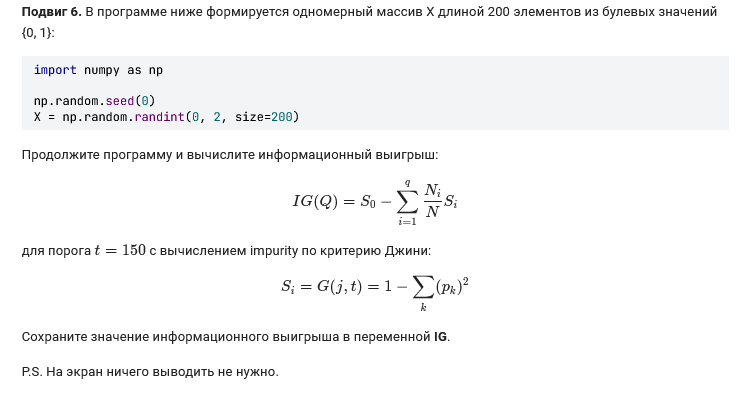

In [20]:
np.random.seed(0)
X = np.random.randint(0, 2, size=200)

# здесь продолжайте программу
t = 150

ln = len(X)
gini = 1 - np.sum((np.bincount(X) / ln)**2)

left_gini = 1 - np.sum((np.bincount(X[:t]) / t)**2)
right_gini = 1 - np.sum((np.bincount(X[t:]) / (ln - t))**2)
w_left = t / ln

IG = gini - (w_left * left_gini + (1 - w_left) * right_gini)
IG

# ---------------------

S = lambda X: 1 - np.sum((np.bincount(X) / len(X))**2)

S0, S_left, S_right = S(X), S(X[:t]), S(X[t:])
w_left = t / ln
IG = S0 - (S_left * w_left + S_right * (1 - w_left))
IG

np.float64(0.01041666666666663)

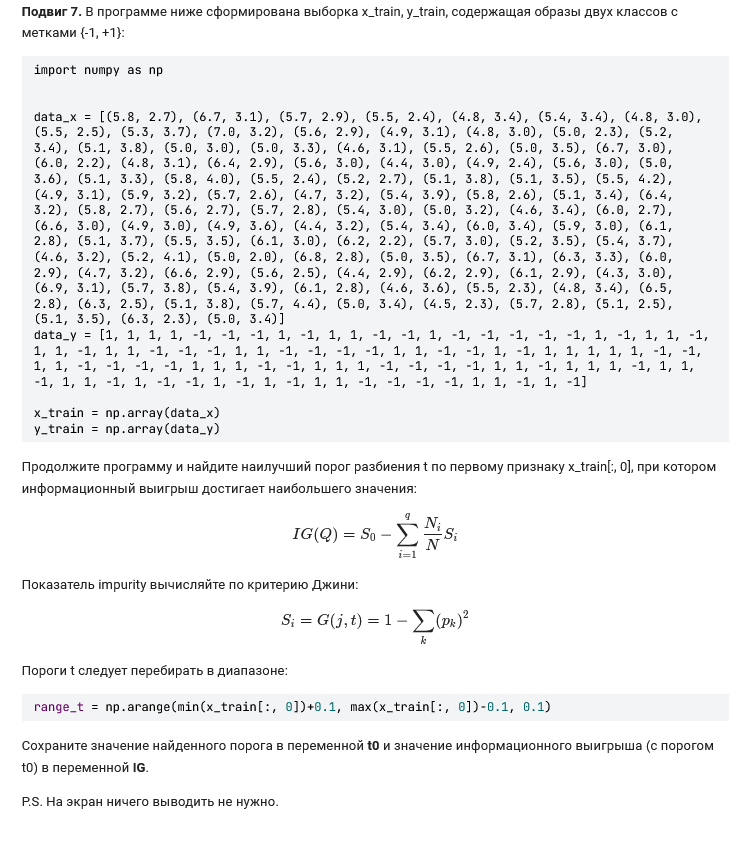

In [11]:
import numpy as np


data_x = [(5.8, 2.7), (6.7, 3.1), (5.7, 2.9), (5.5, 2.4), (4.8, 3.4), (5.4, 3.4), (4.8, 3.0), (5.5, 2.5), (5.3, 3.7), (7.0, 3.2), (5.6, 2.9), (4.9, 3.1), (4.8, 3.0), (5.0, 2.3), (5.2, 3.4), (5.1, 3.8), (5.0, 3.0), (5.0, 3.3), (4.6, 3.1), (5.5, 2.6), (5.0, 3.5), (6.7, 3.0), (6.0, 2.2), (4.8, 3.1), (6.4, 2.9), (5.6, 3.0), (4.4, 3.0), (4.9, 2.4), (5.6, 3.0), (5.0, 3.6), (5.1, 3.3), (5.8, 4.0), (5.5, 2.4), (5.2, 2.7), (5.1, 3.8), (5.1, 3.5), (5.5, 4.2), (4.9, 3.1), (5.9, 3.2), (5.7, 2.6), (4.7, 3.2), (5.4, 3.9), (5.8, 2.6), (5.1, 3.4), (6.4, 3.2), (5.8, 2.7), (5.6, 2.7), (5.7, 2.8), (5.4, 3.0), (5.0, 3.2), (4.6, 3.4), (6.0, 2.7), (6.6, 3.0), (4.9, 3.0), (4.9, 3.6), (4.4, 3.2), (5.4, 3.4), (6.0, 3.4), (5.9, 3.0), (6.1, 2.8), (5.1, 3.7), (5.5, 3.5), (6.1, 3.0), (6.2, 2.2), (5.7, 3.0), (5.2, 3.5), (5.4, 3.7), (4.6, 3.2), (5.2, 4.1), (5.0, 2.0), (6.8, 2.8), (5.0, 3.5), (6.7, 3.1), (6.3, 3.3), (6.0, 2.9), (4.7, 3.2), (6.6, 2.9), (5.6, 2.5), (4.4, 2.9), (6.2, 2.9), (6.1, 2.9), (4.3, 3.0), (6.9, 3.1), (5.7, 3.8), (5.4, 3.9), (6.1, 2.8), (4.6, 3.6), (5.5, 2.3), (4.8, 3.4), (6.5, 2.8), (6.3, 2.5), (5.1, 3.8), (5.7, 4.4), (5.0, 3.4), (4.5, 2.3), (5.7, 2.8), (5.1, 2.5), (5.1, 3.5), (6.3, 2.3), (5.0, 3.4)]
data_y = [1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, 1, -1, -1, 1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1]

x_train = np.array(data_x)
y_train = np.array(data_y)

# здесь продолжайте программу
range_t = np.arange(min(x_train[:, 0])+0.1, max(x_train[:, 0])-0.1, 0.1)

S = lambda y: 1 - np.sum((np.bincount((y + 1) // 2) / len(y)) ** 2)

IGs = np.zeros(len(range_t))
xi0 = x_train[:, 0]
S0 = S(y_train)

for i, t in enumerate(range_t):
    t_left_mask, t_right_mask = xi0 < t, xi0 >= t
    t_left, t_right = np.sum(t_left_mask), np.sum(t_right_mask)

    if t_left > 0 and t_right > 0:
        S_left, S_right = S(y_train[t_left_mask]), S(y_train[t_right_mask])
        IGs[i] = S0 - (S_left * t_left / len(y_train) + S_right * t_right / len(y_train))

idx_max = np.argmax(IGs)
t0, IG = range_t[idx_max], np.max(IGs)

print(t0, IG)

5.499999999999996 0.30432172869147656


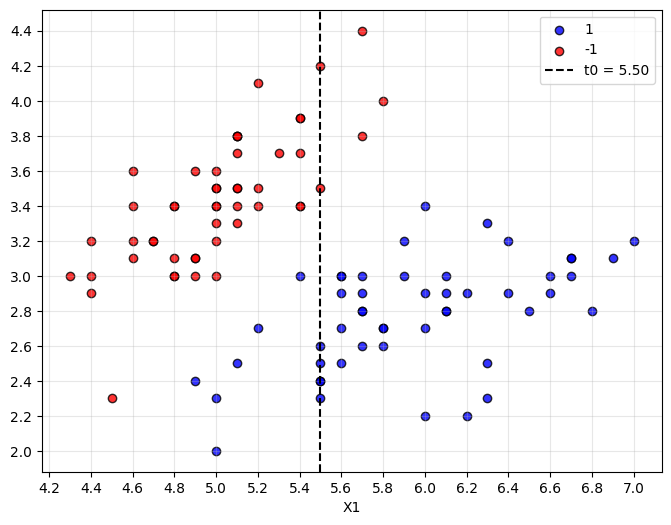

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

pos = (y_train == 1)
neg = (y_train == -1)

plt.figure(figsize=(8, 6))
ax = plt.gca()

# # Способ 1: plt.gca() (текущая ось)
# ax = plt.gca()

# # Способ 2: Создать явно
# fig, ax = plt.subplots()

# # Способ 3: Через figure
# fig = plt.gcf()  # Get Current Figure
# ax = fig.gca()

ax.scatter(x_train[pos, 0], x_train[pos, 1], c='blue', label='1', edgecolor='k', alpha=0.8)
ax.scatter(x_train[neg, 0], x_train[neg, 1], c='red', label='-1', edgecolor='k', alpha=0.8)
ax.axvline(t0, color='black', linestyle='--', label=f't0 = {t0:.2f}')

ax.set_xlabel('X0')
ax.set_xlabel('X1')
ax.legend()

ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.grid(True, alpha=0.3)
plt.show()